# 2. Method 1: Spectrum Binning, Feature Hashing and OMS

## Goals:

In this notebook, we'll be exploring the following three core concepts:

1. [What Open Modification Search (OMS) is, and why it can be computationally expensive.](#21-open-modification-search-(OMS))

2. [How nearest neighbor algorithms work, and how they can be applied to OMS.](#22-clustering)

3. [Why raw mass spectra aren't compatible with clustering algorithms,](#why-vectorize-spectra) [and how Spectral Hashing enables spectra to be clustered.](#step-2-feature-hashing)

## Background

In order to efficiently go through the content in this notebook, we'll define a few terms and their contexts within the tutorial.

- *Sparse and Dense Vectors*:

  - A *dense vector* is a vector where most of the elements are non-zero. For example, `[1, 2, 3, 4]` is a dense vector because all elements are non-zero.

  - A *sparse vector* is a vector where most of the elements are zero. For example, `[0, 0, 3, 0, 0, 0, 7]` is a sparse vector because most elements are zero.


In [33]:
# @title Run this cell to import all necessary packages

#%pip install matplotlib

import spectrum_utils.plot as sup
from pyteomics import mzml
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from rapidhash import rapidhash
from IPython.display import display, Latex
from util import *

import importlib
import SpectrumWithTransformations as swt_module
import SpectrumWithTransformations
from spectrum_utils.proforma import Modification
from util import prove_similarity_preservation_plots_and_statistics

importlib.reload(swt_module)

<module 'SpectrumWithTransformations' from '/home/avni/source/repos/MS_spectra_encoding/SpectrumWithTransformations.py'>

## 2.1 Open Modification Search (OMS)

### 2.1.1 Spectral library search

For this tutorial, we'll be searching a data file where a single protein ([Carbonic Anhydrase](https://www.uniprot.org/uniprotkb/P00921/entry)) was digested with trypsin, then analyzed using LC-MS/MS. We start with a set of MS2 spectra, which we'll call *experimental spectra* (although they're also referred to as *query spectra*), and it's our job to try and identify these spectra by searching the data.

In order to identify peptides in the experimental data, we will compare the experimental spectra to *library spectra* in a spectral library. A spectral libary is a collection of spectra that are annotated with the peptides that gave rise to each spectrum. By comparing experimental spectra against library spectra, you can determine which peptides are present in your experimental data.  A full library search requires E*L comparisons, where E is the number experimental spectra and L is the number of library spectra. However, if both your spectral library and your experimental data are large, this can be a time consuming process!

In order to make the search less computationally expensive, we limit the comparisons. For each experimental MS2 spectrum, we know the mass of the peptide that was isolated and fragmented to generate the spectrum. For the library spectrum, we know the theoretical mass of the peptide that is associated with the spectrum. So, we can restric out spectrum-spectrum comparisons so that only library spectra where the peptide mass is close to the experimental spectrum's precursor mass are considered for comparison. This makes the search less computationally expensive, and therefore much faster!

We performed such a search. However, after it was done, we noticed that while we identified some of the spectra, corresponding to almost every peptide that can be produced by digesting Carbonic Anhydrase, a large portion of the spectra in our data go unmatched. What is happening here?

### 2.1.2 Post-translational modifications and open modification search

The answer is post-translational modifications, or PTMs\*. 

When we only looked for unmodified peptides, we had a relatively constrained set of theoretical spectra. However, once we start considering PTMs, our search space explodes. Any given PTM could appear on multiple residues. A peptide could even bear two or more PTMs. While PTMs are common, and biologically important, they make search considerably more difficult.

One way to account for PTMs is through **Open Modification Search (OMS).**

In OMS, every peptide in the database is considered as a potential match to every MS2 fragmentation spectrum. When a peptide-spectrum match is found, you can look for *mass shifts* to identify PTMs. All possible modifications are implicitly considered. You can imagine that this is very useful for discovering unexpected or novel modifications, but it comes at a cost - it is *very* computationally expensive because we can no longer reduce the number of spectrum-spectrum comparisons by filtering based on precursor mass.

### Sidebar: Database Search and Post-Translational Modifications

#### Database Search

- *Database Search* is a way to check if a peptide from your sample already exists within a database.

  - That is, if you have a spectrum but don't know its identity, checking the relevant databases (eg. humans for human samples, e. coli for e. coli samples) allows you to use someone else's identification ("annotation", rather) of that spectrum.

    - This is done via a variety of algorithms (depends on the tool you're using) to determine how close of a match a spectrum is to the database's annotated spectrum.
    
    - Note that in traditional proteomics, we can safely consider only peptides from the database with the same mass as our fragmented spectra.

#### Post-Translational Modifications (PTMs)

- *Post Translational Modifications (PTMs)* are chemical "add-ons" to proteins after being synthesized. They allow a given protein to diversify and be useful far past the dictates of its transcription and synthesis, especially given that they are reversible. 

  - *PTMs* are also studied for their uses in cell signalling and dynamic regulation of protein function.
  
  - For a less abstract, numerical example of what PTMs are - an oxygen atom as a PTM on a peptide is called oxidation. Oxidation shifts the mass of the peptide by a certain $\text{m/z}$. So if a peak is at $\text{m/z} = 230$ with charge $z$, adding an oxygen atom (~16 Da) will shift it to approximately $230 + 16/z$.


## 2.2  Clustering Spectra

Instead of comparing every experimental spectrum to every possible library in our database, what if we only compared them to a subset of of library spectra? If we could simplify our spectral library in such a way that we found a group of spectra that could be used to represent all other spectra in the library? Then, we only need to compare our experimental spectrum against this small subset of library spectra.

How would we go about this? The first step would be to find **clusters**, or groups of library spectra that are similar to one another. We can cluster all of our *library spectra* together based on their similarity, and then for each *experimental spectrum* we want to identify, we only need to compare it to one representative spectrum  from each cluster (TODO: ANN-SOLO actually compares it to the centroid of each cluster, not an actual spectrum. It's unclear if we need to really hone in on this distinction).

To reiterate - if we know the identity of one spectra in a group ahead of time then we have a good idea of the identity of every spectrum in that cluster. This allows us to make just a single (or a few) comparisons per cluster instead of to every peptide in every cluster.

This approach is similar to the approach of [ANN-SoLo](https://pubs.acs.org/doi/full/10.1021/acs.jproteome.9b00291). This notebook will track closely with the methods used by ANN-SoLo, but the concept of clustering spectra is used much more broadly. [TODO: insert references to other papers that use clustering, for OMS or other applications]

<center><img src="ANN-SoLo-Graphical-Abstract.jpeg" width="685" height="400"></center>

### 2.2.1 Clustering == Lego Sorting

To understand clustering better, imagine you're building a large Lego set with ~2,000 pieces.

*The naive approach:*
* Dump all pieces out at once
* For each instruction, search through the entire pile to find the piece you need

*The clustering approach:*
* Dump all pieces out at once
* First, sort pieces into piles by shape (2x4 studs, 1x2 studs, etc.)
* For each instruction, go directly to the relevant pile

If you grab any piece from a pile, it's representative of all pieces in that pile. This lets you quickly skip irrelevant piles. Now imagine 2,000,000 pieces — the efficiency gain becomes enormous.

> There's a balance between "too specific" (too many small piles) and "too generic" (piles with mixed pieces). The same applies to clustering spectra.

<center><img src="./lego-clusters.png" style="max-width:50vw;" alt="Lego Sorting"></center>


Note that not all pieces in a particular cluster are identical, but they're fairly close to one another! The same is true for spectra in a cluster - they may not be identical, but they're similar enough that we can make the same identification for all spectra in the cluster.

To reiterate:

| Lego | Spectra |
|:---:|:---:|
| Group similar pieces into piles | Group similar spectra into clusters |
| Identify one piece per pile | Identify one spectrum per cluster (using traditional search) |
| All pieces in pile share that identity | All spectra in cluster share that peptide identity |


---

### 2.2.2 A natural question arises: *How do we cluster spectra?*

Before we get deep into this, let's see what it looks like to simply represent points in space. We can use lists of numbers in python (and math more generally) to do this.

For example, a point X = 10 like so:

```python
X = 10
list = [X]
plot(list)
```

![](X.png)


With Y:


```python
X = 10
Y = 20

list = [X, Y]
plot(list)
```

![](Y.png)


And so on and so forth to basically represent as many dimensions as we want. When we get into points in 4 dimensions and higher, we can't visualize them as easily like we do in 1d, 2d, and 3d, but we will primarily just represent them as lists of numbers (or vectors, as they're more commonly called).

---


Let's now return to the question at hand

The first step in building clusters is to determine which spectra are most similar to one another. In the case of mass spectra, it's not obvious how to do this! If a mass spectrum has a peak at 1000 m/z, and another spectrum has a peak at 1000.5 m/z, does this make them similar, or different? Should we focus more on the exact mass of the peaks, or the intensities?


We need some way of taking the complex data contained in a mass spectrum and reducing it down into a format that is easier to work with. Namely, lists of numbers. For this example, we'll try and represent mass spectra by two numbers, aka dimensions. That will allow us to represent a spectrum as a point in two-dimensional space, and will enable us to build clusters. The graphic below shows what this might look like.

<table style="border: none; border-collapse: collapse;">
<tr style="border: none;">
<td style="border: none; text-align: center; vertical-align: top; padding: 10px;">
<img src="Clustering-1.jpeg" height="1000"><br>
<em>Here, we represent every spectrum in 2 dimensions. For dimension one, we sum up every peak below 500 m/z. For dimension 2, we sum up every peak above 500 m/z. This gives us a 2 dimensional representation of each spectrum. We'll start with two known library spectra that represent peptides A and B.</em>
</td>
<td style="border: none; text-align: center; vertical-align: top; padding: 10px;">
<img src="Clustering-2.jpeg" height="1000"><br>
<em>Here, we start adding more and more spectra. By transforming every new spectrum into the same two-dimensional space, it's easy to compare the incoming experimental spectra to the library spectra that represent A and B, and see which of the library spectra the experimental spectrum is more similar to.</em>
</td>
</tr>
</table>

## 2.2.3 - Spectrum Binning

The clustering example above reveals an important requirement, that every spectrum must be represented as a list of the **same length**, where each position means the same thing across all spectra. Only then can we meaningfully compare them. This is given by the fact that we were plotting them Dim 1 and Dim 2, and every spectrum had a value for both of those dimensions. We cannot have some spectra with values for Dim 1 and Dim 2, and other spectra with values for Dim 3 and Dim 4. That would make it impossible to compare them.

We do this by dividing the m/z axis into fixed-width bins and recording each bin's intensity:

* Bin 99: m/z 99–100 → intensity 0
* Bin 100: m/z 100–101 → intensity 1200
* Bin 101: m/z 101–102 → intensity 500
* Bin 102: m/z 102–103 → intensity 0

This gives us a vector like $[..., 0 , 1200, 500, 0, ...]$ where we've just divided the m/z axis into bins of 1 Da width, and recorded the intensity in each bin. Since spectra can only go up to ~2000 m/z, we can represent every spectrum as a fixed vector of length 2000, where each position corresponds to a specific m/z bin, and 0 at a slot = no intensity at any m/z's that fall into that bin.

**Why keep the zeros?** It might seem wasteful. Why not just list the intensities we actually observed? The problem: a bare list like $[1200, 500]$ loses all m/z information. We'd have no idea *which m/z* those intensities came from. The zeros are placeholders that tie each value to a specific m/z range. Also, since every spectrum is represented as a vector of the same length, we can meaningfully compare them, as we mentioned above.

--- 

M/z is continuous domain, meaning that there are infinite points between an m/z of 0 (the lowest m/z over all possible spectra) and 2000, our maximum m/z value over all possible spectra. 

We need some way to turn a continuous range into discrete bins. This process is called **binning**. 

One way to bin is to divide the m/z values into bins of 1 Th each(a Thompson (Th) is a unit in m/z space) like we did above.

<!-- In the cell below, we show what this looks like as a mass spectrum and as a binned vector (first few dimensions shown explicitly). -->

Now, let's start looking at some real data. We'll begin by loading a mass spec data file. It is the one we described earlier, where a single protein was digested and analyzed via LC-MS/MS

Failed to convert matplotlib figure to Plotly; falling back to matplotlib display


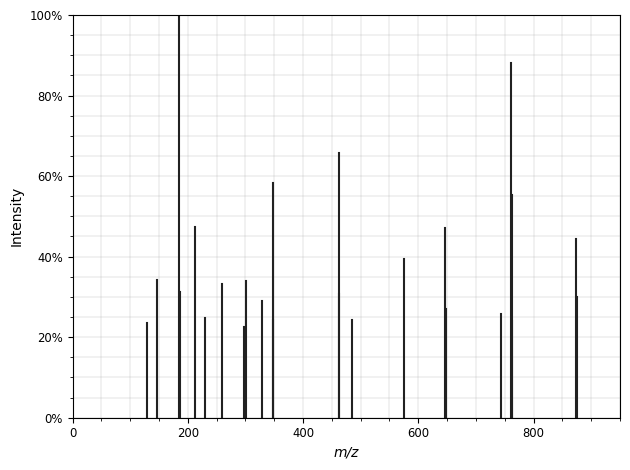

In [34]:
# @title The get_MS2_object function takes in a path and a scan number. This scan number tells it to retrieve the MS2 corresponding to the scan number from that mzML file.

# TODO: Add a note warning people that this will take a while to run the first time, since it has to read in the mzML file and find the scan. After the first time, it will be much faster since the mzML file is cached in memory.

full_calibrated_mzml_path = '04-17-23_CA_Tryp_HCD_10min_CLEAN-calib.mzML' # Throughout our examples, we'll use this as our one sample mzml file. 

ms2_spectrum_5672 = get_MS2_object(mzml_path=full_calibrated_mzml_path, scan=5672)

plot_MS2(ms2_spectrum=ms2_spectrum_5672)

Grab the intensity and mz arrays from the object above:

In [63]:
# grab the m/z values for each peak from the ms2 object
spectrum_mz = ms2_spectrum_5672.mz
# grab the intensity values for each peak from the ms2 object
spectrum_int = ms2_spectrum_5672.intensity

# Display the first 10 m/z peaks  as a table
df = pd.DataFrame({'spectrum_mz': spectrum_mz, 'spectrum_int': spectrum_int})
display(df.style.format({'spectrum_mz': '{:.2f}', 'spectrum_int': '{:.2f}'}))

,spectrum_mz,spectrum_int
0,129.10,2174.82
1,147.11,3145.84
2,185.16,9230.92
3,186.17,2883.78
4,213.16,4380.56
5,229.12,2282.99
6,260.20,3063.12
7,298.14,2072.46
8,300.16,3142.87
9,328.19,2672.69


Recall that our goal is to determine the distance between two spectra (to eventually cluster them) by representing each spectrum as a point in space. 

We'll follow the same approach as we did in our [toy example above](#223---spectrum-binning)


In the case that we use bins of 1 Th (rounding to nearest integer) for the data produced by the code cell above, we get the following vector representation of the spectrum:

$$
\begin{align*}
\text{Bin 129:} & \quad \text{m/z } 129\text{–}130 \quad (\text{intensity} = 2174.818) \\
\text{Bin 147:} & \quad \text{m/z } 147\text{–}148 \quad (\text{intensity} = 3145.84) \\
\text{Bin 185:} & \quad \text{m/z } 185\text{–}186 \quad (\text{intensity} = 9230.925) \\
& \quad \vdots \\
\end{align*}
$$
All unnamed bins have an intensity of 0.

---

#### Binning Strategies

We've shown various motivations for why we need to bin spectra, but throughout, we've simply defaulted to using 1 Th bins. Let's now explore the implications of this choice, and what happens if we use different binning strategies.

##### Approach 1: Rounding to nearest 1 Th (integer bins)
$$
\begin{align}
& \text{Approach 1: Rounding to nearest integer (1 Th bins)} \\[0.5em]

& \text{Here's a list with 2000 zeroes filled in: } &\quad [\underset{0}{0}, \underset{1}{0}, \underset{2}{0}, \ldots, \underset{1999}{0}, \underset{2000}{0}] \\[0.5em]
& \text{Now, let's add a sample of such values at each index:} & \quad [\underset{0}{0}, \ldots, \underset{129}{2174.818}, \ldots, \underset{147}{3145.84}, \ldots, \underset{2000}{0}] 
\end{align}
$$
*Using bins this wide takes lot of accuracy away, and results in quite a few "collisions."*

##### Approach 2: Rounding to nearest 0.01 Th
$$
\begin{align}
& \text{Approach 2: Rounding to nearest 0.01 Th} \\[0.5em]


& \text{Here's a list with 88,000 zeroes filled in: } &\quad [\underset{0}{0}, \underset{1}{0}, \underset{2}{0}, \ldots, \underset{199999}{0}, \underset{200000}{0}] \\[0.5em]
& \text{Now, let's add a sample of such values at each index:} & \quad [\underset{0}{0}, \ldots, \underset{12910}{2174.818}, \ldots, \underset{14711}{3145.84}, \ldots, \underset{200000}{0}] 
\end{align}
$$


# Define why good or bad? -> def collisions.

See note in utils.py re. this


Binning visualization:

<video controls>
  <source src="Binning.mp4" type="video/mp4">
</video>


=== Pairwise Spectrum Collision Analysis ===
File: Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML
Spectra analyzed: 100
Total pairs compared: 4,950

--- Bin Size = 500.0 Da ---
  Mean collision rate per pair: 98.91%
  Median collision rate: 100.00%
  Max collision rate: 100.00%
  Pairs with >50% collision: 4,842 (97.8%)

--- Bin Size = 1.0 Da ---
  Mean collision rate per pair: 13.95%
  Median collision rate: 10.53%
  Max collision rate: 100.00%
  Pairs with >50% collision: 145 (2.9%)

--- Bin Size = 0.01 Da ---
  Mean collision rate per pair: 5.19%
  Median collision rate: 0.00%
  Max collision rate: 100.00%
  Pairs with >50% collision: 52 (1.1%)

--- Improvement ---
  Reduction in mean collision rate (0.01 vs 1.0 Da): 62.8%
  Change in mean collision rate (500.0 vs 1.0 Da): -608.9%


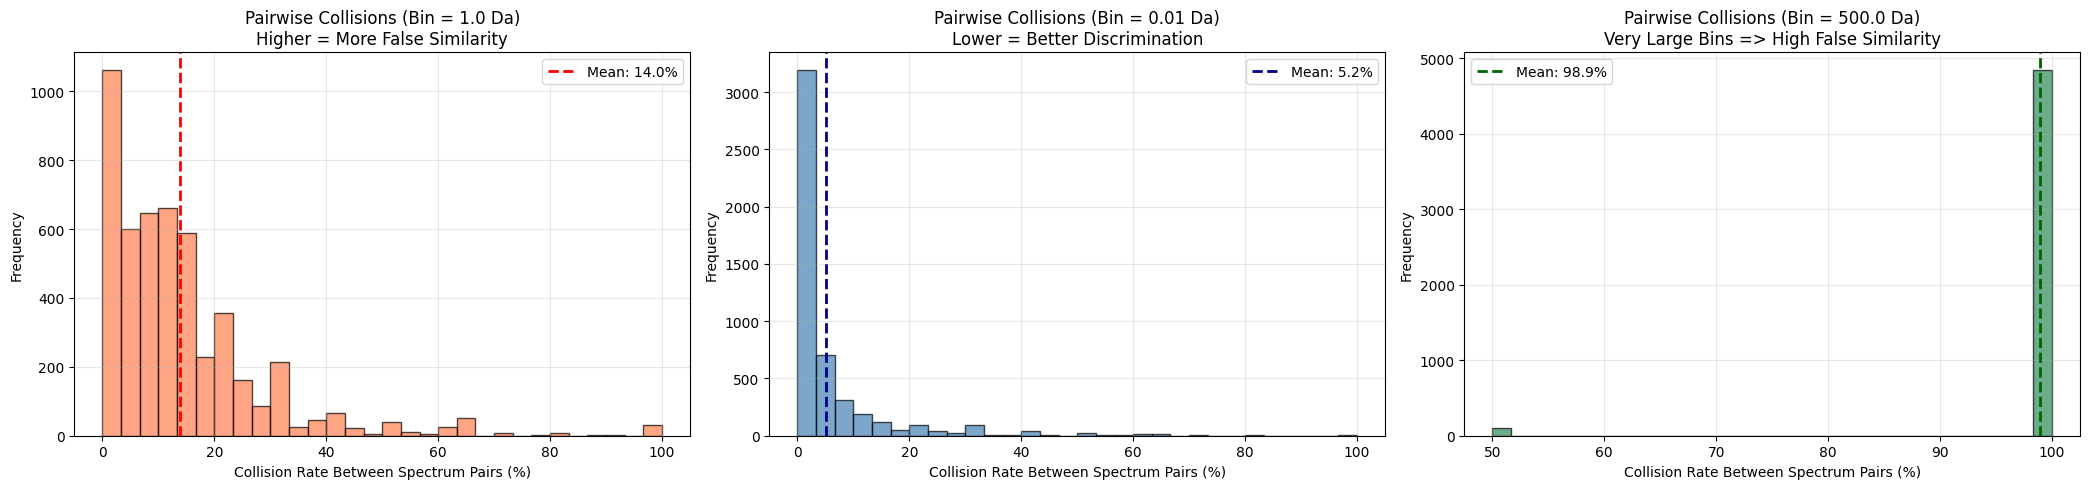

In [36]:
# @title Run this to see the difference in collisions between widths
plot_and_show_statistics_for_collisions("Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML", max_spectra=100)

#### Why collision rate between any spectrum pairs? Why not collision within a spectrum?

(TODO: Clearly define collisions!)

(TODO: We can talk about collisions within a spectrum too! This might be an easier example, as you can show one spectrum with two peaks inside a bin, and show how the distinction gets lost when "coarse" binning is performed)

Our goal is eventually to cluster our spectra, regardless of the bin size. We will soon see that with coarse bins, many spectra that should be in different clusters end up in the same cluster because they appear identical.

Consider two spectra, A and B, each with only one peak:
- Spectrum A has a peak at 90.41 m/z
- Spectrum B has a peak at 90.42 m/z

| Bin Width | Spectrum A | Spectrum B | Result |
|:-----------:|:------------:|:------------:|:--------:|
| 1.0 Da | bin 90 | bin 90 | Collision! Both spectra appear identical |
| 0.01 Da | bin 9041 | bin 9042 | No collision. Spectra are correctly distinguished |

To reiterate: with coarse bins, spectra that are actually different can appear similar. This is clearly a false positive; fine bins preserve the distinction between spectra.

#### Why do we want at most 1 peak per bin anyway?

When each bin contains at most one peak, we preserve **maximum information**. If multiple peaks fall into the same bin, one intensity overwrites another in some way (either we sum intensities or we take the most recent) and we lose data. 

Finer-grained buckets reduce collisions:

1 Da => 880 buckets

0.1 Da => 8,800 buckets

0.01 Da => 88,000 buckets

This demonstrates why we need a smaller bin size. However, we can't just make bins arbitrarily small, we must choose a size that is both fine enough to preserve information and realistic for mass spectrometer accuracy.

Note that mass spectrometers have physical precision limitations too. While a spectrometer might output a value like $ m/z =  10.023130 $, it cannot actually distinguish measurements to that level of precision. In practice, the precision of an m/z value depends on they type of mass spectrometer that was used, with precision ranging from whole Th (1 m/z) down to thousandths of a Thompson!

In [37]:
WIDTH_OF_BIN = 0.01
LENGTH = int(max(spectrum_mz) // WIDTH_OF_BIN +1) # integer rounding up one.
print(f"We have to fit our m/zs into bins by rounding them to the nearest {WIDTH_OF_BIN}")
print(f"The length of our (simulated) array will be {LENGTH}")

We have to fit our m/zs into bins by rounding them to the nearest 0.01
The length of our (simulated) array will be 87550


## 2.5 Ann-SoLo Approach

Now that we have chosen 0.01 Da bins, we can represent that particular spectrum which we plotted and analyzed earlier as a list with length 88,000. We can also call these "dimensions," and note that we've put just one spectrum in an 88,000-dimensional space. 

You might guess that this is a massive problem for clustering and computational efficiency, and is the main motivation behind the ANN-SoLo approach.

What if, instead of using 88,000 dimensions, we had a *magical function* that could compress our spectra into a lower-dimensional space while preserving their relative distances? 

This would make it so clusters of spectra that WOULD have clustered in this ultra-high-dimensional space, also cluster in the lower dimansional space. This is where *feature hashing* comes in. This would allow us to cluster spectra much more efficiently, especially given the fact that this is all in the context of *Open Modification Search*, so our search space is that much larger. We will see this in action later, but I wanted to motivate this idea first.


<figure style="text-align:center">
  <img src="https://pubs.acs.org/cms/10.1021/acs.jproteome.9b00291/asset/images/medium/pr9b00291_0001.gif" width="685" />
  <figcaption style="font-size:1.0em;">ANN-SoLo Plan.</figcaption>
</figure>

We'll be implementing the code for the two steps shown above:

*Spectrum Binning*: Convert spectrum to sparse vector using fine m/z bins (we've already seen numerical examples of this!)

*Feature Hashing*: Compress sparse vector to much smaller, fixed-size vector


### Step 1: Spectrum Binning

**Goal**: Convert spectrum to sparse vector using fine m/z bins

We've already chosen our bin width (0.01 Da). Now we'll define a function to convert m/z values to their binned index.

For example: 129.103 m/z → index 12910

In [38]:
# @title Conversion to sparse vector

def to_idx(mz):
    """
    Convert m/z value to a sparse vector index.
    """
    # concretely: 129.103 // 0.01 == 12910
    return int(mz // WIDTH_OF_BIN) # rounds down to nearest 0.01.

#### Sparse Vector Optimization

We're going to make another optimization before we continue with the feature hashing approach. With 88,000 possible bins but only 24 peaks in this spectrum, most bins are empty. Storing ~88,000 zeros is wasteful right now as well, so instead we'll use a dictionary mapping `{mz_bin: intensity}`.

This **dictionary** stores only the non-zero entries:

Instead of:
```
[0, 0, 0, ..., 2174.818, 0, 0, ..., 3145.84, 0, 0, ..., 0]  # 88,000 elements!
```

We store:
```
{12910: 2174.818, 14711: 3145.84, ...}  # Only 24 entries
```

In [39]:
# @title Create the sparse representation: map from m/z indices to intensities

mz_intensity_map = {}
# Populate the sparse vector with our spectrum data
for i, mz in enumerate(spectrum_mz):
    # Convert each m/z to its corresponding index
    mz_index = to_idx(mz)
    # Store the intensity
    mz_intensity_map[mz_index] = spectrum_int[i]

What does this look like?

In [40]:
# @title Run to visualize the dictionary 

from IPython.display import display
rows = []
for bin_idx, intensity in sorted(mz_intensity_map.items()):
    orig_mz = next((mz for mz in spectrum_mz if to_idx(mz) == bin_idx), None)
    rows.append({'m/z bin': bin_idx, 'Intensity': intensity, 'Original m/z': orig_mz})
df_mz = pd.DataFrame(rows)
display(df_mz.style.format({'Intensity': '{:.3f}', 'Original m/z': '{:.4f}'}))

print(f"Total entries: {len(mz_intensity_map)} (instead of ~88,000 zeros!)")

,m/z bin,Intensity,Original m/z
0,12910,2174.818,129.1023
1,14711,3145.840,147.1128
2,18516,9230.925,185.1649
3,18616,2883.776,186.1681
4,21315,4380.564,213.1598
5,22911,2282.987,229.1184
6,26019,3063.123,260.1971
7,29814,2072.459,298.1401
8,30015,3142.870,300.1557
9,32818,2672.693,328.1873


Total entries: 24 (instead of ~88,000 zeros!)


#### Step 1 Complete! 

 We have a sparse, binned, vector representation of our spectrum.

 ---
 

#### Step 2: Feature Hashing

Now for the second step of the pipeline:

**Goal:** Compress the sparse vector (with indices up to 88,000) into a fixed-size vector of 10,000 dimensions.

#### Why do we need this?

Our dense dictionary is memory efficient, but we still have a problem. **It's only dense in name, not functionality.**


Clustering algorithms need fixed-size vectors. You can't easily compute distances between dictionaries with different keys. As such, the potential dimensionality is still huge. Even with only 24 entries, those indices span 0-88,000 and will need to be translated back into vectors for clustering.

Here, I will once again remind you of our *magic function* from earlier. [Click this to review that cell again](#25-ann-solo-approach)

#### Hash Function

A *hash function* has 3 main properties.

1. **Randomness/Uniformity**: They do not produce outputs of "groups" based on the input. 

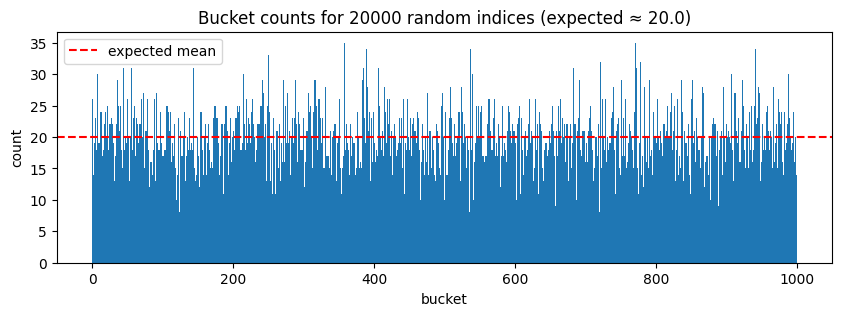

In [41]:

# Let's hash some values, and see how uniformly they distribute into buckets

# We will use a hash function called rapidhash, which is widely used.
HASH_BUCKETS = 1000

def bucket_for_index(idx: int) -> int:
    return rapidhash(int(idx).to_bytes(8, "little")) % HASH_BUCKETS # encode ints => bytes for rapidhash


N = 20000
sample = np.random.choice(88000, size=N, replace=False)
buckets_sample = [bucket_for_index(int(i)) for i in sample]
counts = np.bincount(buckets_sample, minlength=HASH_BUCKETS)

plt.figure(figsize=(10,3))
plt.bar(np.arange(HASH_BUCKETS), counts, width=1.0)
plt.axhline(N / HASH_BUCKETS, color="red", linestyle="--", label="expected mean")
plt.xlabel("bucket")
plt.ylabel("count")
plt.title(f"Bucket counts for {N} random indices (expected ≈ {N/HASH_BUCKETS:.1f})")
plt.legend()
plt.show()

2. **Deterministic**: Same input -> same output every time

In [42]:
hashed_string = rapidhash("this is the same string".encode())
same_hashed_string = rapidhash("this is the same string".encode())

print(hashed_string)
print(same_hashed_string)

assert(hashed_string == same_hashed_string)
print("Both hashes are identical")

9532297966430686050
9532297966430686050
Both hashes are identical


3. **Incredibly Fast**: Efficiently computable

In [43]:
import timeit


def hash_varied_strings():
    for _ in range(100000):
        hash(f"this is string number {np.random.randint(0, 100000)}")


hash_time_varied = timeit.timeit(hash_varied_strings, number=1)


print(f"Time taken to hash 100,000 different strings: {hash_time_varied} seconds")

Time taken to hash 100,000 different strings: 0.2805884680001327 seconds


#### Our Magic Function == Hash Function

We wanted to map down from our sparse vector to a much lower dimensional one.

<details>
<summary><strong>[Optional] Why 10,000 buckets?</strong></summary>

It's somewhat arbitrary, but we aim to balance two concerns:
- Large enough to minimize collisions (different peaks hashing to the same bucket)
- Small enough to be computationally efficient for clustering

10,000 is a good middle ground for typical spectrum.

---

</details>

A hash function maps any sparse index to a fixed range of buckets. Here we use 10,000 buckets, so every index from 0 to 88,000 will be mapped to a bucket between 0 and 9,999.:

$$\text{hash}(12910) \rightarrow 347 \quad \text{(bucket between 0 and 9,999)}$$

$$\text{hash}(14711) \rightarrow 102 \quad \text{(another bucket)}$$

Similar spectra (which we'd like to identify for clustering purposes) will have similar hash vectors because they share many of the same m/z bins, *which will hash to the same buckets* because of the deterministic nature of hash functions.

In [44]:
HASH_BUCKETS = 10000

#### The hash function

We'll use `rapidhash`, a fast hash function, combined with the modulo operator to map any sparse index to a bucket in the range `[0, 9999]`.

In [45]:
def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.
    
    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 9,999)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')
    
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % HASH_BUCKETS

In [46]:
# @title Example: see how large indices get mapped to small buckets
print(f"Sparse index 12910 → bucket {hasher(12910)}")
print(f"Sparse index 14711 → bucket {hasher(14711)}")
print(f"Sparse index 87550 → bucket {hasher(87550)}")

Sparse index 12910 → bucket 9429
Sparse index 14711 → bucket 4719
Sparse index 87550 → bucket 6354


#### Handling collisions

What happens when two different m/z bins hash to the same bucket? This is called a **collision**. 

We handle collisions by **adding the intensities together**. As we will see in a minute, this is acceptable because it, on average, happens rarely enough that it preserves similarity between vectors, which is the key idea behind combining clustering and hashing.

In [47]:
# @title Populate our final hash vector with intensities, handling collisions by summation

# Initialize our final hash vector with all zeros
hash_vector = [0] * HASH_BUCKETS 

# Populate the hash buckets with intensities from our sparse map
for sparse_idx, intensity in mz_intensity_map.items():
    # Map the sparse index to a bucket
    bucket_idx = hasher(sparse_idx)
    
    # Add intensity to that bucket (handles collisions by summation)
    hash_vector[bucket_idx] += intensity

In [48]:
# @title Display the hash vector

non_zero_buckets = [(i, val) for i, val in enumerate(hash_vector) if val > 0]

print(f"Hash vector has {len(non_zero_buckets)} non-zero buckets out of {HASH_BUCKETS} total\n")

nonzero_hash_df = pd.DataFrame(non_zero_buckets, columns=['Bucket', 'Intensity'])
pd.set_option('display.float_format', lambda x: f'{x:.2f}')
display(nonzero_hash_df)

Hash vector has 24 non-zero buckets out of 10000 total



,Bucket,Intensity
0,1127,8133.11
1,1455,4098.93
2,1792,2831.66
3,2246,2672.69
4,2568,2226.69
5,3315,5098.79
6,3832,4380.56
7,3836,2240.40
8,4046,3632.96
9,4478,2072.46


#### Step 2 complete!

We now have a fixed-size hash vector that we can use for clustering!

---

## 2.6 Summary of the Spectrum Binning + Feature Hashing Pipeline


| Step | Representation | Size |
|------|----------------|------|
| **Original** | (m/z, intensity) pairs | 24 peaks |
| **Step 1: Binning** | Sparse vector (used dictionary for optimization) | ~88,000 |
| **Step 2: Hashing** | Fixed-size vector | 10,000 dimensions |


## 2.7 How We Actually Cluster Spectra Part 2 

Our goal in this notebook is not to implement ANN-SoLo to actually cluster spectra, but rather to understand how this is a fairly simple way to embed spectra for machine learning tasks like clustering. 

That being said, we will briefly prove to ourselves that this approach works.

We recently claimed that hashing "preserves similarity," meaning spectra that would be clustered together in the original high-dimensional space also cluster together in the compressed space. Let's show this, first by answering the question from the beginning "How do we actually cluster spectra?" and then by showing that hashing preserves clusters.

#### Measuring similarity with cosine similarity

The gold standard for measuring similarity between vectors is *cosine similarity*.

It relies on the notion of a *dot product* to measure how similar two vectors are:

$$\vec{x} \cdot \vec{z} > \vec{x} \cdot \vec{y} \implies \vec{x} \text{ is more similar to } \vec{z} \text{ than to } \vec{y}$$

*Cosine similarity* is just a normalized dot product (scaled between -1 and 1).

<details>
<summary><strong>[Optional] Click to see the full cosine similarity formula</strong> </summary>

$$\cos(\theta) = \frac{\vec{x} \cdot \vec{z}}{|\vec{x}| |\vec{z}|}$$

where $\theta$ is the angle between vectors. 

$\cos(\theta = 0) = 1$ => Identical direction

$\cos(\theta = 90) = 0$ => Perpendicular

$\cos(\theta = 180) = -1$ => Opposite direction

---

</details>

**Example:**

$\vec{x} = [0, 500, 0, 1200] \quad \text{(Spectrum A)}$

$\vec{z} = [0, 480, 0, 1190] \quad \text{(Spectrum B - similar)}$

$\vec{y} = [100, 30, 2000, 0] \quad \text{(Spectrum C - different)}$

**Dot products:**

$\vec{x} \cdot \vec{z} = (0)(0) + (500)(480) + (0)(0) + (1200)(1190) = 1,668,000$

$\vec{x} \cdot \vec{y} = (0)(100) + (500)(30) + (0)(2000) + (1200)(0) = 15,000$

Since $1,668,000 \gg 15,000$, spectra A and B would be clustered together, and spectrum C would be separate in this 4-dimensional space.


#### A Short Note on Clustering Algorithms

For demonstration, we can use any clustering algorithm under the sun, and we could even make our own. For this, we've (somewhat arbitrarily) chosen hierarchical clustering, which builds a tree of clusters based on similarity like so:

![Hierarchical Agglomerative Clustering](https://media.geeksforgeeks.org/wp-content/uploads/20260119171439693920/bc.webp)

What this means is that we calculated pairwise cosine similarities between all spectra, and then grouped spectra together based on how similar they were.
When you compute pairwise similarities between spectra, you get a symmetric matrix:

|       | Spec0 | Spec1 | Spec2 | Spec3 |
|-------|:-----:|:-----:|:-----:|:-----:|
| Spec0 | 1.0   | 0.8   | 0.3   | 0.6   |
| Spec1 | 0.8   | 1.0   | 0.4   | 0.5   |
| Spec2 | 0.3   | 0.4   | 1.0   | 0.7   |
| Spec3 | 0.6   | 0.5   | 0.7   | 1.0   |

And we then group spectra together based on these similarities until they all become one big cluster.

Note that in the traditional ANN-SoLo approach, they 


<details><summary><strong>[Optional] Click to see the step-by-step hierarchical clustering process</strong></summary>

We see that Spec0 and Spec1 are most similar, so we group them first.

Clusters: `[(Spec0, Spec1), Spec2, Spec3]`

Using average linkage (a common method), we average the other similarities:

Similarity to Spec2: (0.3 + 0.4) / 2 = 0.35
Similarity to Spec3: (0.6 + 0.5) / 2 = 0.55


|                | (Spec0, Spec1) | Spec2 | Spec3 |
|----------------|:--------------:|:-----:|:-----:|
| (Spec0, Spec1) | 1.0            | 0.35  | 0.55  |
| Spec2          | 0.35           | 1.0   | 0.7   |
| Spec3          | 0.55           | 0.7   | 1.0   |


Highest similarity is 0.7 (Spec2-Spec3). Merge them.

Clusters: `[(Spec0, Spec1), (Spec2, Spec3)]`

|                | (Spec0, Spec1) | (Spec2, Spec3) |
|----------------|:--------------:|:--------------:|
| (Spec0, Spec1) | 1.0            | 0.45           |
| (Spec2, Spec3) | 0.45           | 1.0            |

Finally, merge the final two clusters at similarity 0.45.

</details>


Click play to go through a visual example (no sound), starting from the top.

<video controls>
  <source src="SimilarityPreservationComplete.mp4" type="video/mp4">
</video>


#### Empirical validation

The code below compares pairwise similarities between spectra in both the original (sparse) and hashed representations. If hashing works, the correlation should be high.

In simpler terms, did you notice that when we went from binned -> binned + hashed spectra, the peaks didn't keep their original spots? We'll show that a hash function actually does this so reliably, that we still KEEP the similarity or dissimilarity property of the original binned spectra. 
- Again, we are **not** comparing binned spectra to binned + hashed, we're following the video exactly, and ensuring that if 2 binned spectra are similar, then their respective hashed versions will also be similar.
    - Like aforementioned, you also cannot actually compare two lists of 88,000 (binned) and 10,000 (binned + hashed) elements. This is another reason why we compare things in their respective "spaces."

> **Note:** Some similarity loss is expected due to hash collisions, but this loss is typically small and acceptable for clustering purposes.

Computing pairwise similarities...



---
### SIMILARITY PRESERVATION METRICS
---
- **Pearson correlation**:  0.9973 (p-value: 0.00e+00)
- **Number of pairwise comparisons**: 44,850
- **Mean absolute error**: 0.0015
---


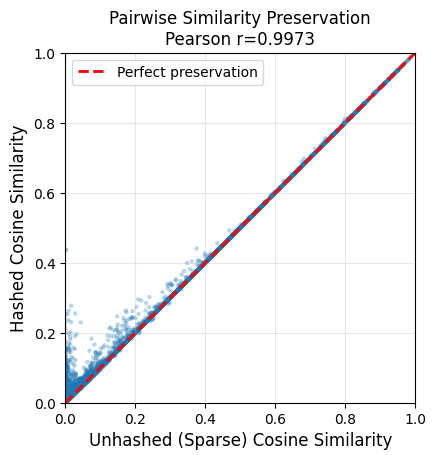

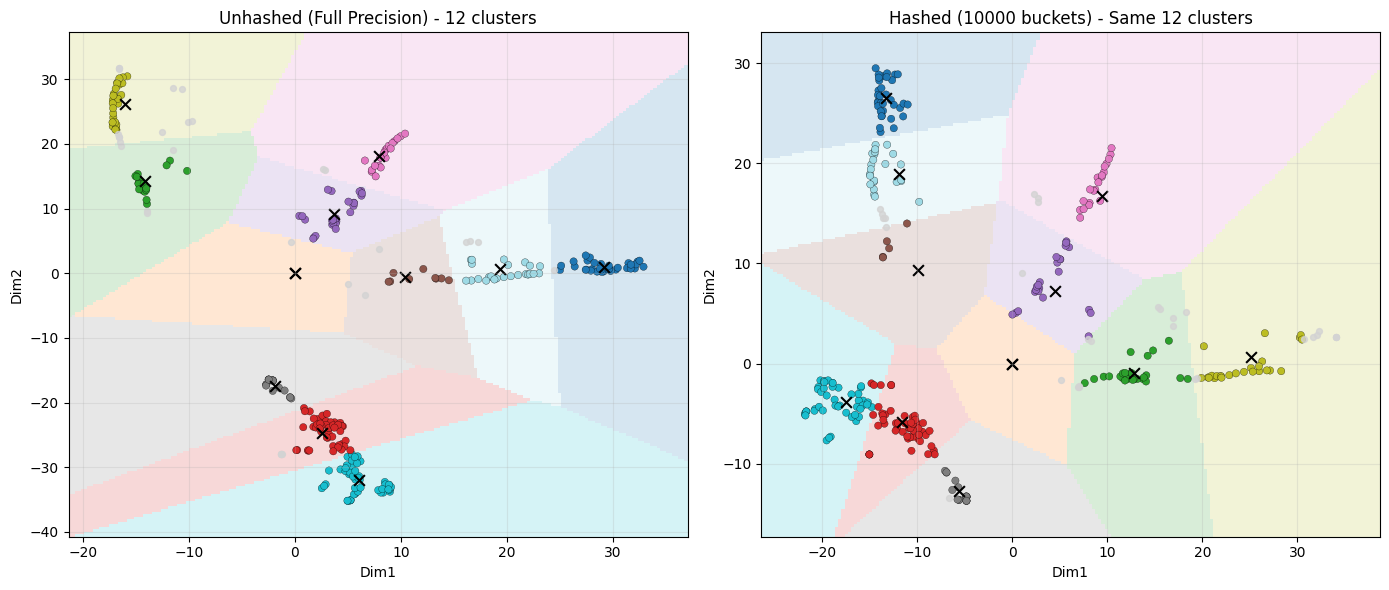

In [49]:
prove_similarity_preservation_plots_and_statistics("Biogen_ALS_Pilot_1A9_020120-calib-averaged.mzML") 

## 2.8 How does this speed up OMS?

Let's return again to our original problem now that we've got this hash vector, defined a similarity metric, and how clustering works.

In fact, let's imagine a fake embedding function:

```python
def embed_spectrum(mz_array: list[float], intensity_array: list[float]) -> list[float]:
    # Step 1: Bin → Step 2: Hash
    # ...
    return hash_vector  # length 10,000
```


**Phase 1: Build the Library (one-time preprocessing)**

1. For all spectra with **known identity** (from a spectral library), we call this function:

```python
hash_vector_library = embed_spectrum(library_spectrum.mz, library_spectrum.intensity)
```

2. Cluster all library hash vectors (we'll use cosine similarity).


> **Lego analogy:** Sort all your known Lego pieces into piles before you start building.

---

**Phase 2: Identify Unknown Spectra (query phase)**

3. For each unknown **query spectrum**:
```python
hash_vector_query = embed_spectrum(query_spectrum.mz, query_spectrum.intensity)
```

4. Find the nearest cluster representative using cosine similarity.

5. If similarity exceeds a threshold → assign the query the peptide identity of that cluster.

> **Lego analogy:** When you need a piece, check which pile it belongs to. All pieces in that pile share ~ the same identity.

---

**To Reiterate: Why does this work for modified peptides?**

A modified peptide shares MOST of its fragment ions with the unmodified version. The modification only shifts a subset of peaks. Because of this shared structure, the hash vectors remain similar enough that modified and unmodified versions cluster together - enabling identification regardless of PTMs.


---

## Worked Example: Spectral Hashing End-to-End

Now let's see the complete pipeline on real data. We'll work with the peptide **AVVQDPALKPLALVYGEATSR**.

Below is its theoretical ion ladder:

In [50]:
make_ion_ladder('AVVQDPALKPLALVYGEATSR')

,b#,b_ion_m/z,b_ion_sequence,y_ion_sequence,y_ion_m/z,y#
0,1,72.04,A,VVQDPALKPLALVYGEATSR,"2,127.18",20
1,2,171.11,AV,VQDPALKPLALVYGEATSR,"2,028.11",19
2,3,270.18,AVV,QDPALKPLALVYGEATSR,"1,929.04",18
3,4,398.24,AVVQ,DPALKPLALVYGEATSR,"1,800.98",17
4,5,513.27,AVVQD,PALKPLALVYGEATSR,"1,685.96",16
5,6,610.32,AVVQDP,ALKPLALVYGEATSR,"1,588.91",15
6,7,681.36,AVVQDPA,LKPLALVYGEATSR,"1,517.87",14
7,8,794.44,AVVQDPAL,KPLALVYGEATSR,"1,404.78",13
8,9,922.54,AVVQDPALK,PLALVYGEATSR,"1,276.69",12
9,10,"1,019.59",AVVQDPALKP,LALVYGEATSR,"1,179.64",11


Let's look at how this ion ladder can be plotted as a "spectrum." The purpose of this is to visualize the spread of m/z values. The intensity values here are meaningless.

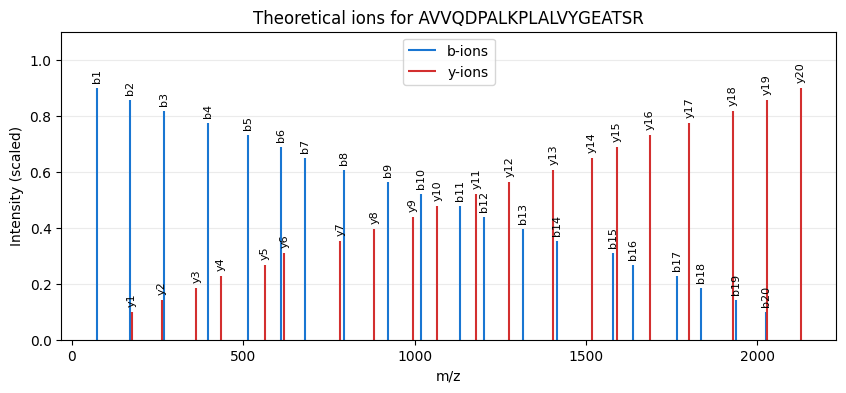

In [51]:
b_mz = [
    72.044114, 171.112528, 270.180942, 398.239520, 513.266463,
    610.319227, 681.356341, 794.440405, 922.535368, 1019.588132,
    1132.672196, 1203.709310, 1316.793374, 1415.861788, 1578.925108,
    1635.946572, 1764.989165, 1836.026279, 1937.073958, 2024.105986
]

y_mz = [
    2127.179698, 2028.111284, 1929.042870, 1800.984292, 1685.957349,
    1588.904585, 1517.867471, 1404.783407, 1276.688444, 1179.635680,
    1066.551616, 995.514502, 882.430438, 783.362024, 620.298704,
    563.277240, 434.234647, 363.197533, 262.149854, 175.117826
]

plot_theoretical_ions(b_mz, y_mz, 'AVVQDPALKPLALVYGEATSR')

Now let's plot a real spectrum and use the theoretical ions above to to annotate it. We'll start with scan 9970, the spectrum of the unmodified AVVQDPALKPLALVYGEATSR peptide.

Failed to convert matplotlib figure to Plotly; falling back to matplotlib display


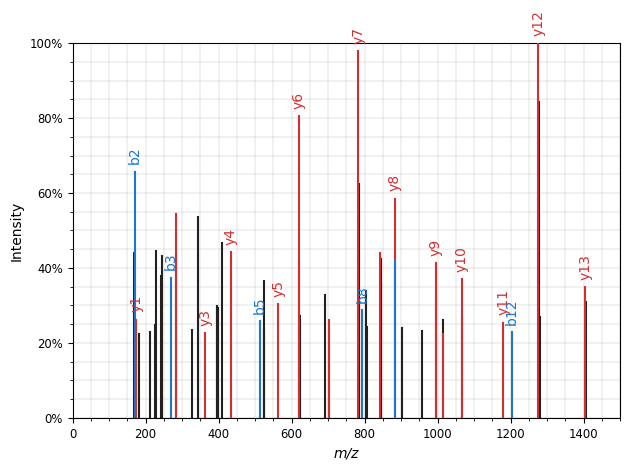

In [52]:
plot_MS2(get_MS2_object(full_calibrated_mzml_path, 9970, peptide = 'AVVQDPALKPLALVYGEATSR'))

Although there is inevitable noise that deviates from the theoretical ion ladder, this spectrum overall aligns really well with the ladder. In other words, **a significant proportion of this spectrum's total intensity is accounted for by the theoretical ion ladder.** Let's now look at a modified version of AVVQDPALKPLALVYGEATSR.

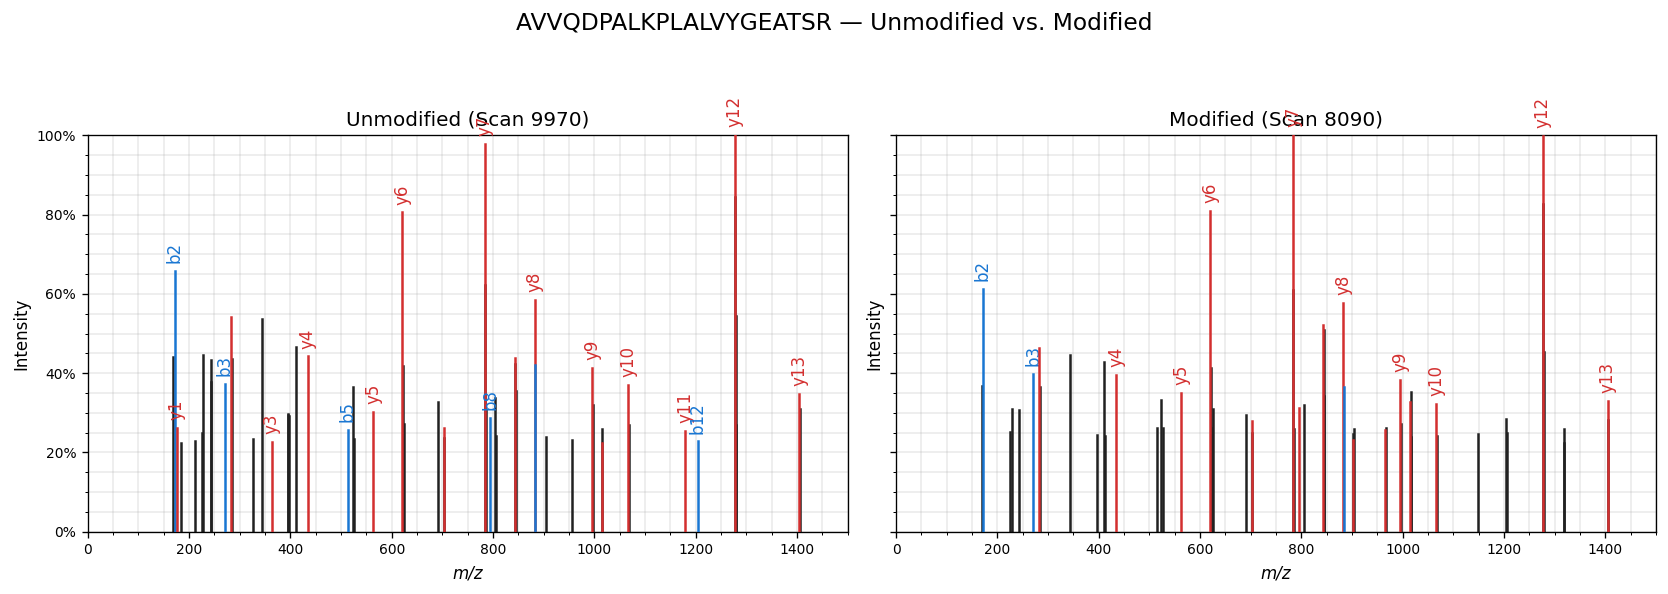

In [53]:

seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 9970, peptide=seq) #AVVQDPALKPLALVYGEATSR
spec_right = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq) #AVVQ[Common Artifact:Deamidation on Q]DPALKPLALVYGEATSR

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 9970 (unmodified peptide)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 9970)")

# Right panel = scan 8090 (modified peptide)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8090)")

fig.suptitle("AVVQDPALKPLALVYGEATSR — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at top
plt.show()

We can repeat that process using an unmodified and modified spectrum from each of the 2 other peptides in our mzml file: IITHPNFNGNTLDNDIMLIK and RMVNNGHSFNVEYDDSQDK.

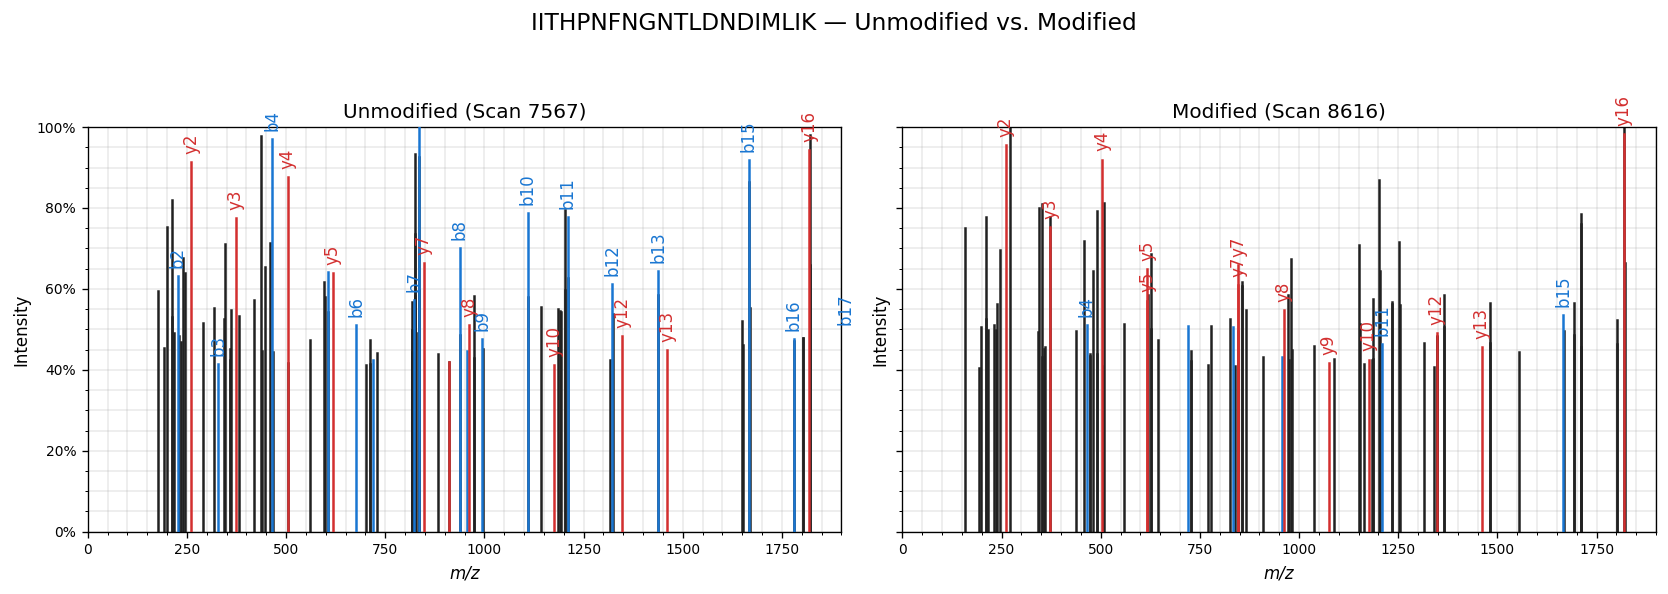

In [54]:

seq = 'IITHPNFNGNTLDNDIMLIK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 7567, peptide=seq) #IITHPNFNGNTLDNDIMLIK
spec_right = get_MS2_object(full_calibrated_mzml_path, 8616, peptide=seq) #[Common Artifact:Carbamyl on X]IITHPNFNGNTLDNDIMLIK

fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 7567 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 7567)")

# Right panel = scan 8616 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 8616)")

fig.suptitle("IITHPNFNGNTLDNDIMLIK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

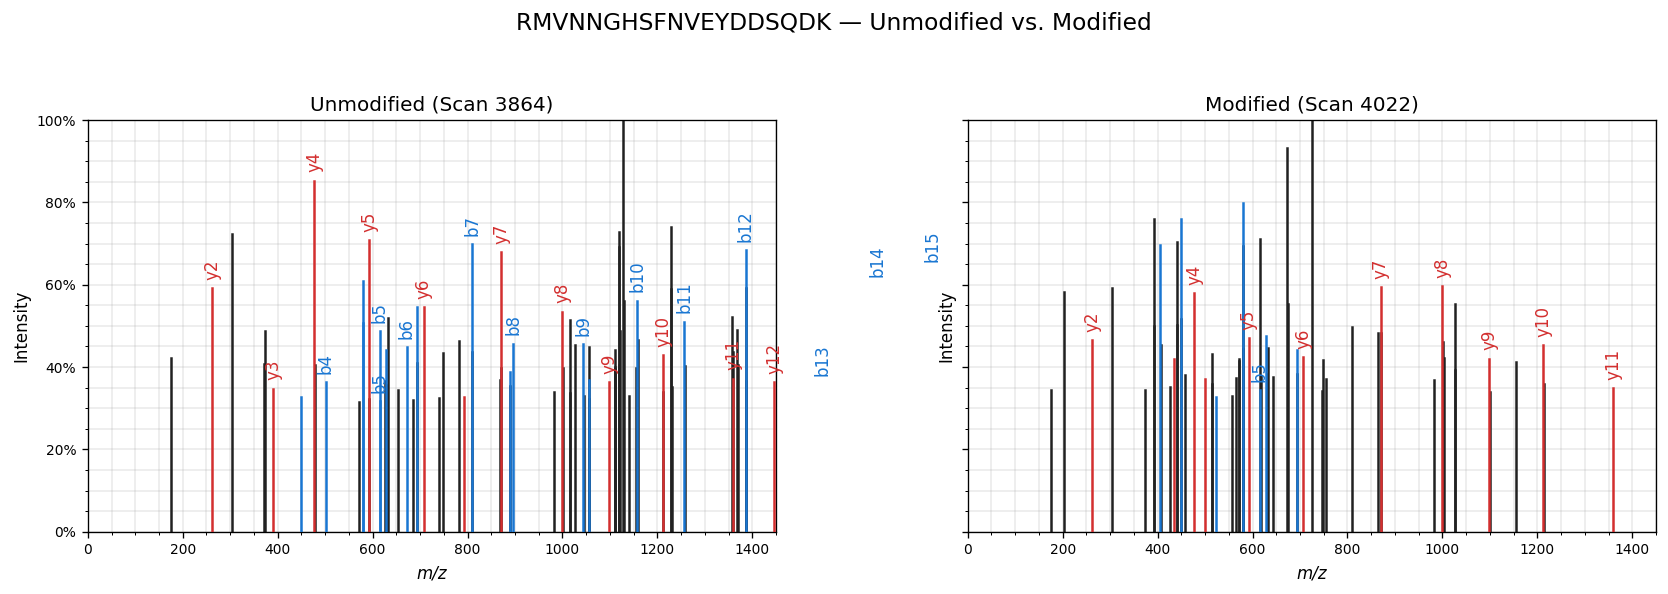

In [55]:

seq = 'RMVNNGHSFNVEYDDSQDK'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq) #RMVNNGHSFNVEYDDSQDK
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq) #RMVNN[Common Artifact:Deamidation on N]GHSFNVEYDDSQDK

# Make two panels with shared zxes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = scan 3864 (unmodified)
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Unmodified (Scan 3864)")

# Right panel = scan 4022 (modified)
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Modified (Scan 4022)")

fig.suptitle("RMVNNGHSFNVEYDDSQDK — Unmodified vs. Modified", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

There are two "trends" you might be noticing by now: <br></br>
1. Generally, when a spectrum (modified or unmodified) is annotated with the theoretical ion ladder for it's associated peptide, there is a significant proportion of that spectrum's intensity that is accounted for by the ion ladder.
2. Unmodified spectra better "match" or are better "accounted for" by the peptide's theoretical ion ladder than modified spectra. But there is not a significant difference.
<br></br>
But what if we were to use the ion ladder of one peptide to annotate the spectrum of a different peptide? Let's try using the theoretical ion ladder of AVVQDPALKPLALVYGEATSR to annotate the spectrum of a modified RMVNNGHSFNVEYDDSQDK peptide. We'll plot that on the right panel. On the left, we'll plot the spectrum of a modified AVVQDPALKPLALVYGEATSR spectrum and annotate it with the AVVQDPALKPLALVYGEATSR ion ladder (just as we did above). In this case, we are plotting spectra from **2 different peptides** and annotating them with **1 ion ladder.**

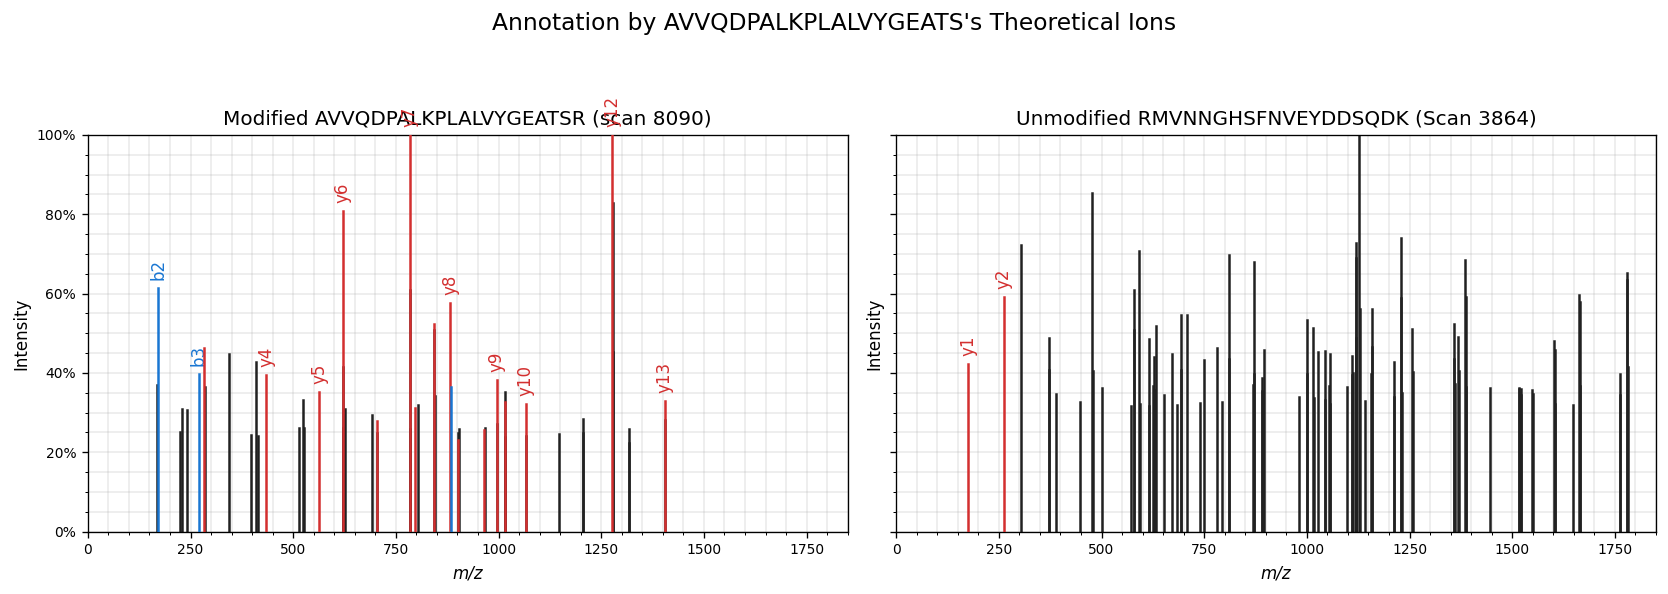

In [56]:
seq = 'AVVQDPALKPLALVYGEATSR'
spec_left  = get_MS2_object(full_calibrated_mzml_path, 8090, peptide=seq)
spec_right = get_MS2_object(full_calibrated_mzml_path, 3864, peptide=seq)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = modified AVVQDPALKPLALVYGEATSR = scan 8090
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("Modified AVVQDPALKPLALVYGEATSR (scan 8090)")

# Right panel = unmodified RMVNNGHSFNVEYDDSQDK = scan 3864
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("Unmodified RMVNNGHSFNVEYDDSQDK (Scan 3864)")

fig.suptitle("Annotation by AVVQDPALKPLALVYGEATS's Theoretical Ions", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])  # leave space at the top for the suptitle
plt.show()

Now we'll annotate the spectrum of the modified RMVNNGHSFNVEYDDSQDK peptide using the theoretical ions of RMVNNGHSFNVEYDDSQDK (on the left) and AVVQDPALKPLALVYGEATSR (on the right).We are plotting **1 spectrum** and annotating it using **2 different theoretical ions from 2 different base peptides.**

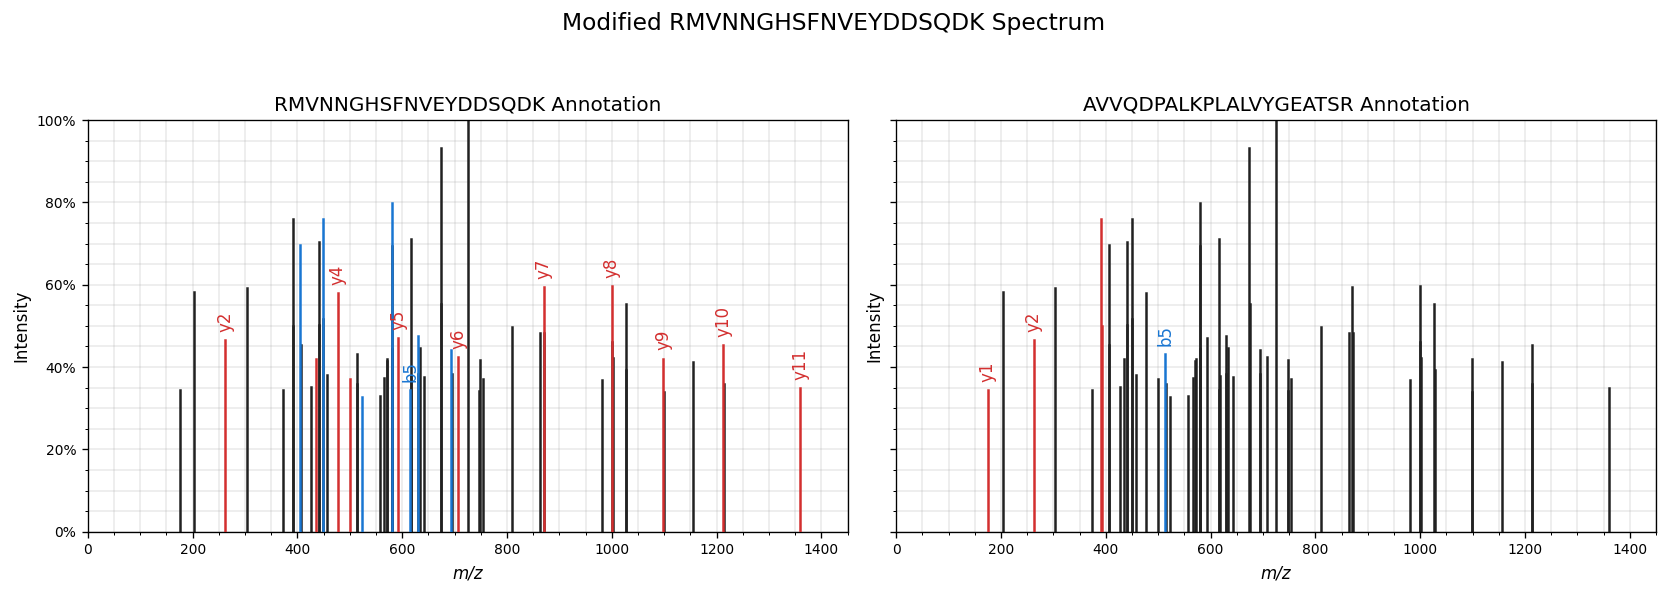

In [57]:
seq_1= 'RMVNNGHSFNVEYDDSQDK'
seq_2 = 'AVVQDPALKPLALVYGEATSR'

spec_left  = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_1)
spec_right = get_MS2_object(full_calibrated_mzml_path, 4022, peptide=seq_2)

# Make two panels with shared axes
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=120, sharex=True, sharey=True)
axes[0].set_xlabel("m/z")
axes[0].set_ylabel("Intensity")

# Left panel = RMVNNGHSFNVEYDDSQDK Annotation, Scan 4022
sup.spectrum(spec_left, ax=axes[0], grid=True)
axes[0].set_title("RMVNNGHSFNVEYDDSQDK Annotation")

# Right panel = AVVQDPALKPLALVYGEATSR Annotation, scan 4022
sup.spectrum(spec_right, ax=axes[1], grid=True)
axes[1].set_title("AVVQDPALKPLALVYGEATSR Annotation")

fig.suptitle("Modified RMVNNGHSFNVEYDDSQDK Spectrum", fontsize=14)
plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

Now, you're probably beginning to notice more meaningful trends. In the first example, where we annotated two different spectra (from different peptides) with the same ion ladder, a much greater proportion of the "matching" spectrum's intensity was accounted for by the ion ladder than of the other spectrum's intensity. In the second example, where we annotated the same spectrum using two different ion ladders (one belonging to the same peptide, and one not), a much greater proportion of the spectrum (annotated by it's associated peptide)'s intensity was accounted for by the ion ladder than of the spectrum (annoted by the other peptide)'s intensity. **Let's begin the binning process:**

In [58]:
# This function should read in an mzml file and return an object of type SpectrumWithTransformations
# Based off of get_MS2_object from Sam Payne lesson 4
def get_SWT_object(
    mzml_path: str,
    scan_number: int,
    full_sequence = None,
) -> "SpectrumWithTransformations":
    
    index = scan_number -1 #scan_number is 1-based, index is 0-based
    with mzml.MzML(mzml_path, use_index=True) as reader: #use_index=True allows us to avoid reading through the entire mzml file
        selected_spectrum = reader.get_by_index(index)
    # Test to see if we accessed the correct scan: PASSED!
    # precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    # print(precursor_mz)
    

    # This finds the cooresponding values in the .mzml file to create our MS2 for a given scan (see the params)
    spectrum_id = selected_spectrum['id']
    retention_time = selected_spectrum['scanList']['scan'][0]['scan start time']
    precursor_mz = selected_spectrum['precursorList']['precursor'][0]['isolationWindow']['isolation window target m/z']
    precursor_charge = int(selected_spectrum['precursorList']['precursor'][0]['selectedIonList']['selectedIon'][0]['charge state'])
    mz_array = np.asarray(selected_spectrum['m/z array'])
    intensity_array = np.asarray(selected_spectrum['intensity array'])
    
    swt_object = SpectrumWithTransformations.SpectrumWithTransformations(
        identifier=spectrum_id,
        scan_number=scan_number,
        precursor_mz=precursor_mz,
        precursor_charge=precursor_charge,
        mz_array=mz_array,
        intensity_array=intensity_array,
        retention_time=retention_time,
        annotation_dictionary=None,
        binned_mz=None,
        hashed_mz=None,
    )

    if full_sequence:
        swt_object = swt_object.annotate_proforma(
            proforma_str = full_sequence,
            fragment_tol_mass = 0.01, # We consider two peaks (actual and theoretical) "equivalent" if they are within +/- 0.01 Da
            fragment_tol_mode = 'Da',
            ion_types = 'by',
            max_ion_charge = max(1, precursor_charge - 1)
        )
    return swt_object

In [59]:
scan_8090 = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)

plot_MS2(scan_8090, title='Scan 8090: Original Spectrum')

In [60]:
WIDTH_OF_BIN = 0.01
def to_idx(num):
    return int(num // WIDTH_OF_BIN)

# Bin the mz
scan_8090.binned_mz = np.empty_like(scan_8090.mz, dtype=int)
for i in range(len(scan_8090.mz)):
    scan_8090.binned_mz[i] = to_idx(scan_8090.mz[i])

# Create a binned_spectrum SWT object for plotting purposes only
binned_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(binned_spectrum.mz)):
    binned_spectrum.mz[i] = scan_8090.binned_mz[i] #Re-writing the mz_array with the binned mz values

# Plot the binned spectrum
plot_MS2(binned_spectrum, 'Scan 8090: Binned Spectrum')


In [61]:
def hasher(num: int) -> int:
    """
    Hash function that maps sparse indices to a fixed number of buckets.

    Input: Large sparse index (e.g., 12910)
    Output: Small bucket index (0 to 9999)
    """
    # Convert integer to bytes for hashing (rapidhash expects byte input)
    byte_representation = int(num).to_bytes(8, 'little')
    # Hash and mod to get bucket index in range [0, hash_buckets-1]
    return rapidhash(byte_representation) % HASH_BUCKETS

# Set-up
hashed_mz = []
hashed_intensity = []
hash_vector = [0] * HASH_BUCKETS
mz_intensity_map = {}
for i, mz in enumerate(scan_8090.mz):
    mz_intensity_map[to_idx(mz)] = scan_8090.intensity[i]

# Hash the mz and add the intensities as we go
for sparse_idx, intensity in mz_intensity_map.items():
    bucket_idx = hasher(sparse_idx)
    hash_vector[bucket_idx] += intensity
    hashed_mz.append(bucket_idx)
    hashed_intensity.append(hash_vector[bucket_idx])

# Update the hashed mz and intensities
scan_8090.hashed_mz = hashed_mz
scan_8090.hashed_intensity = hashed_intensity

# Create a hashed_spectrum SWT object for plotting purposes only
hashed_spectrum = get_SWT_object(
    mzml_path=full_calibrated_mzml_path,
    scan_number = 8090,
    full_sequence = 'AVVQ[Deamidated]DPALKPLALVYGEATSR',
)
for i in range (len(hashed_spectrum.mz)):
    hashed_spectrum.mz[i] = scan_8090.hashed_mz[i] #Re-writing the mz_array with the hashed mz values
    hashed_spectrum.intensity[i] = scan_8090.hashed_intensity[i] #Re-writing the intensity_array with the summed intensity values

# Plot the hashed spectrum
plot_MS2(hashed_spectrum, 'Scan 8090: Hashed Spectrum')

/home/avni/source/repos/MS_spectra_encoding/.venv/lib64/python3.13/site-packages/plotly/matplotlylib/renderer.py:645: UserWarning:

Looks like the annotation(s) you are trying 
to draw lies/lay outside the given figure size.

Therefore, the resulting Plotly figure may not be 
large enough to view the full text. To adjust 
the size of the figure, use the 'width' and 
'height' keys in the Layout object. Alternatively,
use the Margin object to adjust the figure's margins.



### Side by side
<img src="Scan8090_Original.png" width="400" height="300">
<img src="Scan8090_Binned.png" width="400" height="300">
<img src="Scan8090_Hashed.png" width="400" height="300">